##### Filter accounts that scrape videos less than 30

In [54]:
import json
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.ticker as ticker

In [55]:
# input_file = "dataset.json"
# output_file = "dataset_filter.json"

# with open(input_file, "r", encoding="utf-8") as f:
#     data = json.load(f)

# user_videos = defaultdict(list)

# for item in data:
#     username = item.get("authorMeta", {}).get("name")
#     if username is not None:
#         user_videos[username].append(item)

# filtered_data = []
# kept_users = 0

# for username, videos in user_videos.items():
#     if len(videos) == 30:
#         filtered_data.extend(videos)
#         kept_users += 1

# with open(output_file, "w", encoding="utf-8") as f:
#     json.dump(filtered_data, f, ensure_ascii=False, indent=2)

# print(f"Original videos: {len(data)}")
# print(f"Kept users: {kept_users}")
# print(f"Filtered videos: {len(filtered_data)}")
# print(f"Saved to: {output_file}")

##### Process the dataset

In [56]:
with open("dataset_filter.json", "r", encoding="utf-8") as f:
    data = json.load(f)

rows = []

for item in data:
    rows.append({
        "username": item["authorMeta"]["name"],
        "followers": item["authorMeta"]["fans"],

        "create_time": pd.to_datetime(item["createTime"], unit="s"),
        "duration": item["videoMeta"]["duration"],

        "views": item["playCount"],
        "likes": item["diggCount"],
        "comments": item["commentCount"],
        "shares": item["shareCount"],

        "caption": item["text"],
        "hashtag": item["hashtags"],
        "musicOriginal": item['musicMeta']['musicOriginal'],
        "coverUrl": item['videoMeta']['coverUrl']
    })

df = pd.DataFrame(rows)
df = df.sort_values(by=["username", "create_time"], ascending=[True, True])

# data[2]['videoMeta']
data = df
data.iloc[0], data.iloc[1], df.columns, data.iloc[0]['views']

(username                                              .sturdy.manz
 followers                                                     4489
 create_time                                    2025-01-26 05:10:18
 duration                                                         0
 views                                                         4138
 likes                                                          160
 comments                                                         1
 shares                                                          15
 caption          ik we argue alla time n shit but ur still fam ...
 hashtag                                          [{'name': 'fyp'}]
 musicOriginal                                                 True
 coverUrl         https://p16-common-sign.tiktokcdn-us.com/tos-m...
 Name: 13379, dtype: object,
 username                                              .sturdy.manz
 followers                                                     4489
 create_time       

##### Analysis of the dataset

In [57]:
followers, views, likes, comments, shares= [], [], [], [], []
for idx, row in data.iterrows():
    followers.append(int(row['followers']))
    views.append(int(row['views']))
    likes.append(int(row['likes']))
    comments.append(int(row['comments']))
    shares.append(int(row['shares']))

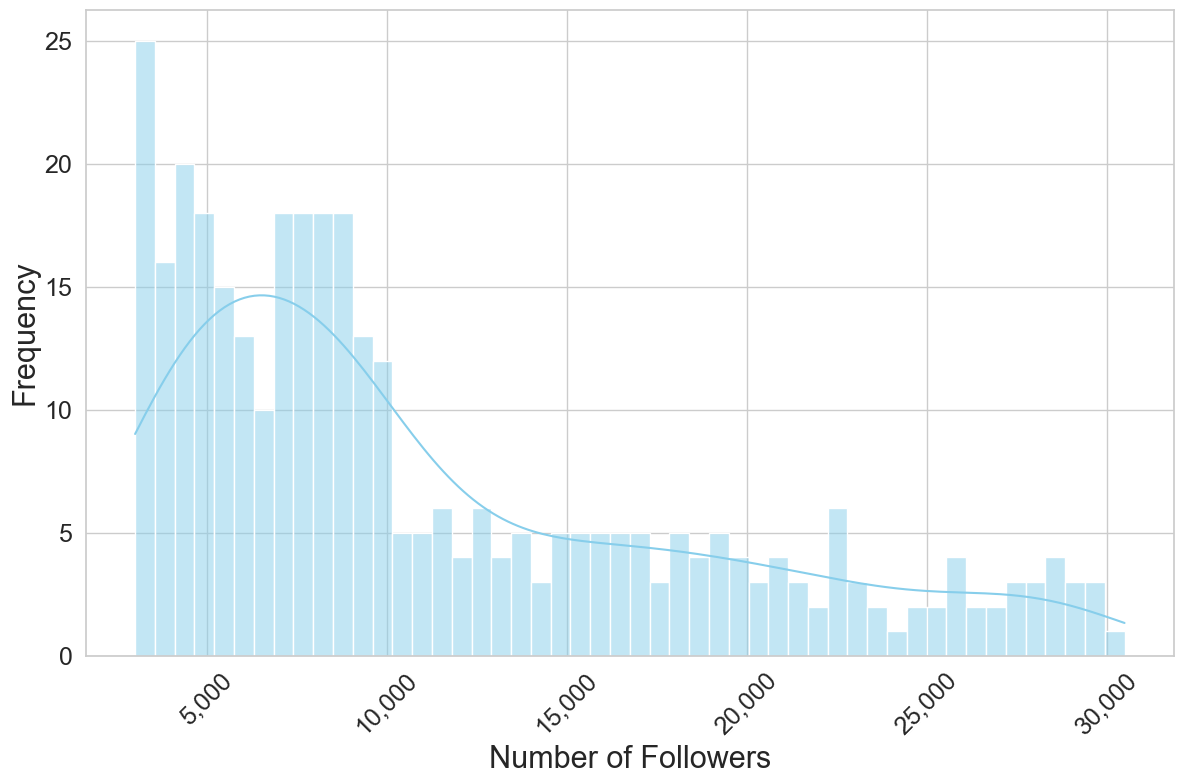

In [58]:
followers = list(set(followers))
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 8))

sns.histplot(followers, kde=True, color='skyblue', bins=50, ax=ax)

ax.set_xlabel('Number of Followers', fontsize=22)
ax.set_ylabel('Frequency', fontsize=22)

ax.tick_params(axis='both', labelsize=18)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### followers of all accounts

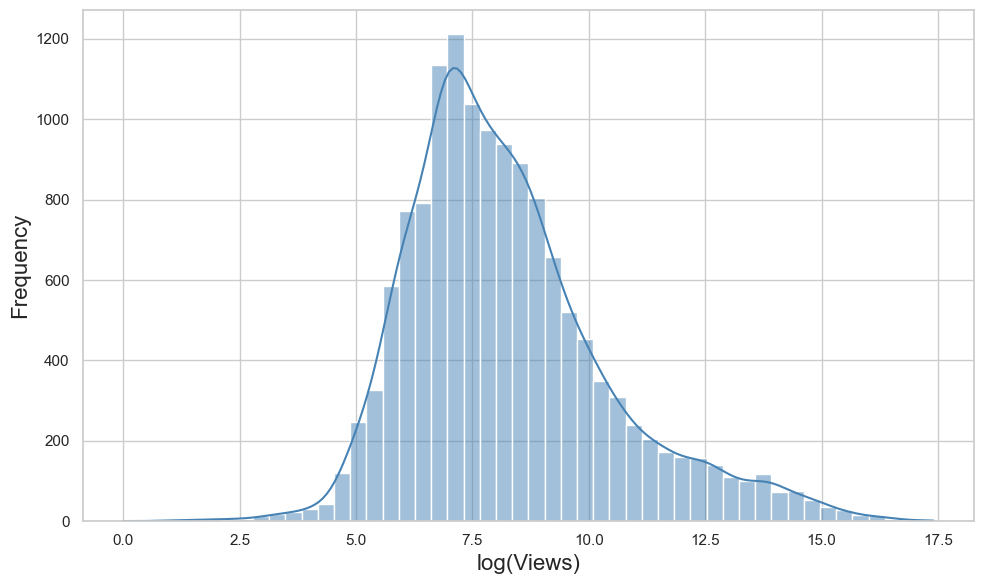

In [59]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

log_views = np.log1p(df["views"])

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(log_views, bins=50, kde=True, color='steelblue')

plt.xlabel("log(Views)", fontsize=16)
plt.ylabel("Frequency", fontsize=16)

plt.tight_layout()
plt.show()

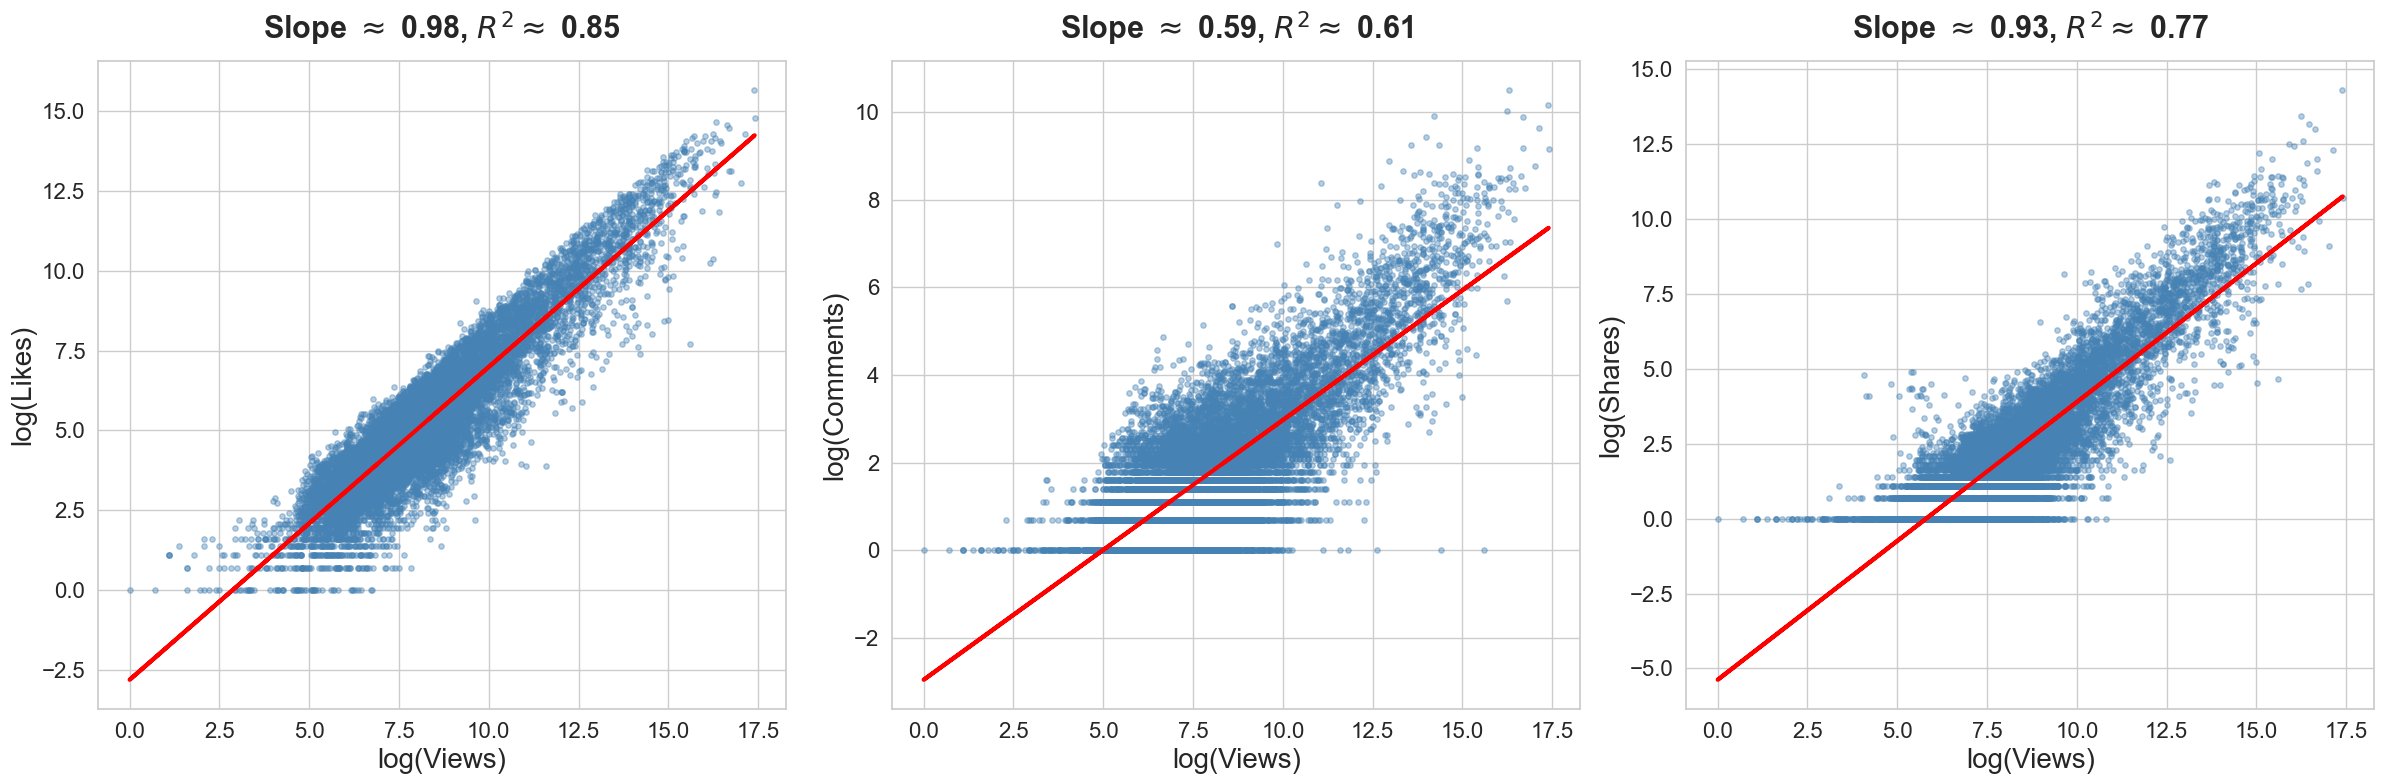

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression

views_arr = np.array(views)
likes_arr = np.array(likes)
comments_arr = np.array(comments)
shares_arr = np.array(shares)

log_views = np.log1p(views_arr)
log_likes = np.log1p(likes_arr)
log_comments = np.log1p(comments_arr)
log_shares = np.log1p(shares_arr)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

def plot_with_fit_subplot(ax, x, y, xlabel, ylabel):
    ax.scatter(x, y, alpha=0.4, s=15, color='steelblue')

    model = LinearRegression()
    x_reshaped = x.reshape(-1, 1)
    model.fit(x_reshaped, y)
    y_pred = model.predict(x_reshaped)

    ax.plot(x, y_pred, color='red', linewidth=3)

    slope = model.coef_[0]
    r2 = model.score(x_reshaped, y)

    ax.set_title(f"Slope $\\approx$ {slope:.2f}, $R^2 \\approx$ {r2:.2f}", fontsize=22, fontweight='bold', pad=15)
    ax.set_xlabel(xlabel, fontsize=20)
    ax.set_ylabel(ylabel, fontsize=20)
    ax.tick_params(axis='both', labelsize=16)

plot_with_fit_subplot(axes[0], log_views, log_likes, "log(Views)", "log(Likes)")
plot_with_fit_subplot(axes[1], log_views, log_comments, "log(Views)", "log(Comments)")
plot_with_fit_subplot(axes[2], log_views, log_shares, "log(Views)", "log(Shares)")

plt.tight_layout()
plt.show()

In [61]:
data1 = df[390:420]

views = []
for idx, row in data1.iterrows():
    views.append(int(row['views']))

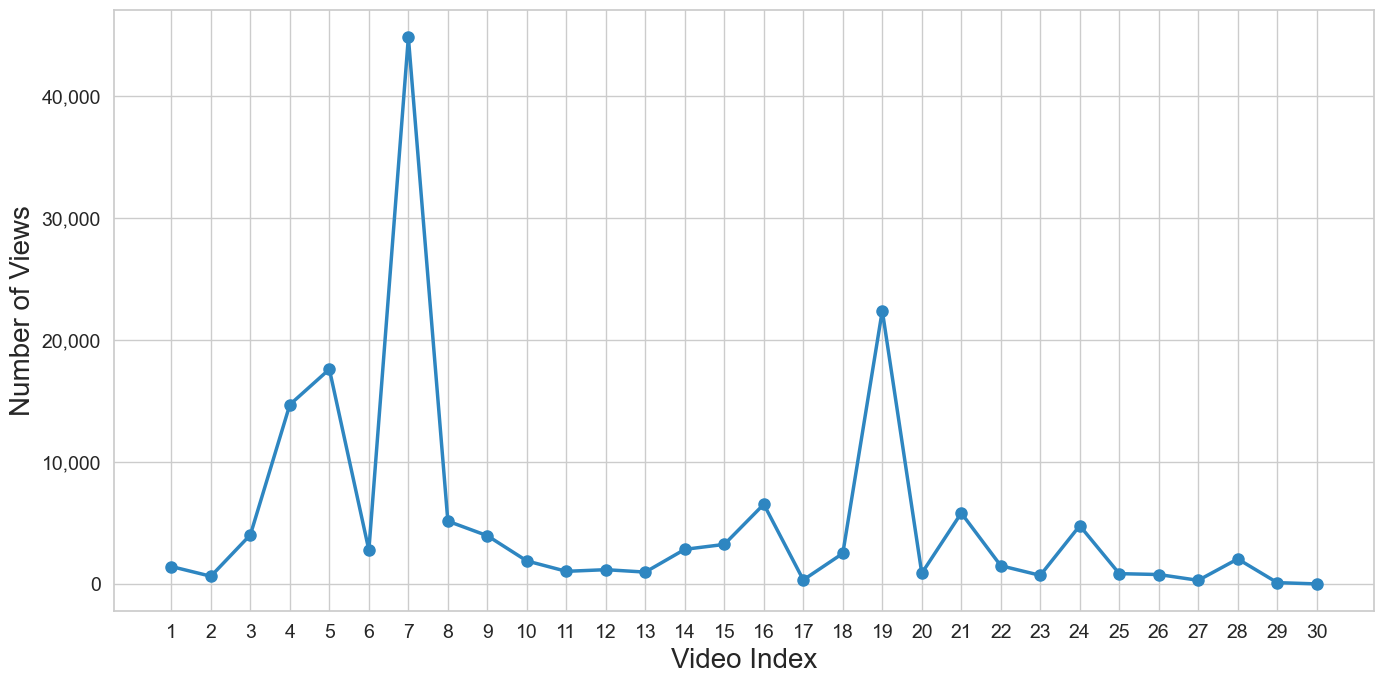

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as ticker

indices = range(1, 31)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(indices, views, marker='o', linestyle='-', color='#2e86c1', linewidth=2.5, markersize=8)

ax.set_xlabel('Video Index', fontsize=20)
ax.set_ylabel('Number of Views', fontsize=20)

ax.set_xticks(indices)
ax.tick_params(axis='both', labelsize=14)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))

plt.tight_layout()
plt.show()

In [63]:
import pandas as pd
import numpy as np

def prepare_tiktok_dataset(df):
    df['create_time'] = pd.to_datetime(df['create_time'])
    df['hour'] = df['create_time'].dt.hour
    df['weekday'] = df['create_time'].dt.weekday
    # df['caption_len'] = df['caption'].str.len().fillna(0)
    # df['hashtag_count'] = df['hashtag'].apply(lambda x: len(x) if isinstance(x, list) else 0)

    def process_user_group(group):
        group['self_like_rate'] = np.where(group['views'] > 0, group['likes'] / group['views'], 0)
        group['self_comment_rate'] = np.where(group['views'] > 0, group['comments'] / group['views'], 0)
        group['self_share_rate'] = np.where(group['views'] > 0, group['shares'] / group['views'], 0)

        rolling_window = group.shift(1).rolling(window=10, min_periods=10)

        group['hist_median_views'] = rolling_window['views'].median()
        group['hist_p70_views'] = rolling_window['views'].quantile(0.70)
        group['hist_p90_views'] = rolling_window['views'].quantile(0.90)

        group['hist_like_rate'] = rolling_window['self_like_rate'].mean()
        group['hist_comment_rate'] = rolling_window['self_comment_rate'].mean()
        group['hist_share_rate'] = rolling_window['self_share_rate'].mean()

        group['video_rank'] = range(1, len(group) + 1)

        return group[(group['video_rank'] >= 11) & (group['video_rank'] <= 30)]

    df_train = df.groupby('username').apply(process_user_group).reset_index(drop=True)

    df_train['explosion_score'] = df_train['views'] / df_train['followers'].replace(0, 1)
    
    df_train['target_log'] = np.log1p(df_train['explosion_score'])

    return df_train

df_final = prepare_tiktok_dataset(data)

print(f"Raw data: {len(data)}，Final data: {len(df_final)}")

Raw data: 13980，Final data: 9320


In [64]:
X = df_final.drop(columns=['username', 'create_time', 'views', 'likes', 'comments', 'shares', 'self_like_rate', 'self_comment_rate', 'self_share_rate'])

In [65]:
X.iloc[0]

followers                                                         4489
duration                                                            21
caption                                my camera shaking🥲 #fypシ゚ #fyp 
hashtag                           [{'name': 'fypシ゚'}, {'name': 'fyp'}]
musicOriginal                                                     True
coverUrl             https://p16-common-sign.tiktokcdn-us.com/tos-m...
hour                                                                23
weekday                                                              1
hist_median_views                                               4810.0
hist_p70_views                                                  8386.1
hist_p90_views                                                 21850.0
hist_like_rate                                                0.060586
hist_comment_rate                                             0.000747
hist_share_rate                                               0.002048
video_

In [66]:
X.to_csv('cleaned_data_ml.csv', index=False, encoding='utf-8')

In [67]:
data.iloc[11]

username                                              .sturdy.manz
followers                                                     4489
create_time                                    2025-04-15 03:13:36
duration                                                        15
views                                                         5708
likes                                                          244
comments                                                         2
shares                                                           1
caption                                 how df i get here? #fypシ゚ 
hashtag                                        [{'name': 'fypシ゚'}]
musicOriginal                                                 True
coverUrl         https://p16-common-sign.tiktokcdn-us.com/tos-m...
hour                                                             3
weekday                                                          1
Name: 13368, dtype: object